# Discretization in Bnpyro

Bnpyro compiles probabilistic programs into Bayesian Networks. Since pyAgrum only supports **discrete variables**, every continuous distribution must be discretized before compilation.

This notebook covers:
1. How discretization works
2. The impact of `n_bins` on precision
3. `MIDPOINT` vs `INTEGRATION`
4. The combinatorial explosion of CPTs
5. `BIN_ADAPTIVE` — automatic reduction
6. `memory_warn_mb` and `memory_limit_mb` — memory protection

In [1]:
import sys, os
if os.path.basename(os.getcwd()) != 'src':
    sys.path.insert(0, 'src')

import io, contextlib
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm as sp_norm

from Bnpyro import BNppl, MIDPOINT, INTEGRATION, BIN_UNIFORM, BIN_ADAPTIVE
from distributions import Normal, Uniform, Beta

## 1. Why discretize?

pyAgrum computes exact inference via **Variable Elimination**, which requires a finite state space for every variable.

Continuous distributions have infinite support — they are approximated by a discrete histogram over `n_bins` equal-width intervals.

The interval is chosen to cover **~99% of the probability mass**:
- `Normal(μ, σ)` → `[μ − 3σ, μ + 3σ]`
- `Uniform(a, b)` → `[a, b]` (exact)
- `Beta, Gamma, ...` → `[μ − 3σ, μ + 3σ]` clipped to support

Each bin probability is computed via the **CDF**: `P(X ∈ [a, b]) = F(b) − F(a)`

## 2. Visualizing discretization

The same `Normal(0, 1)` distribution approximated with 4, 8, and 16 bins.  
Bars represent the discrete probabilities `P(X ∈ bin)`, the black curve is `density × Δx` (same scale).

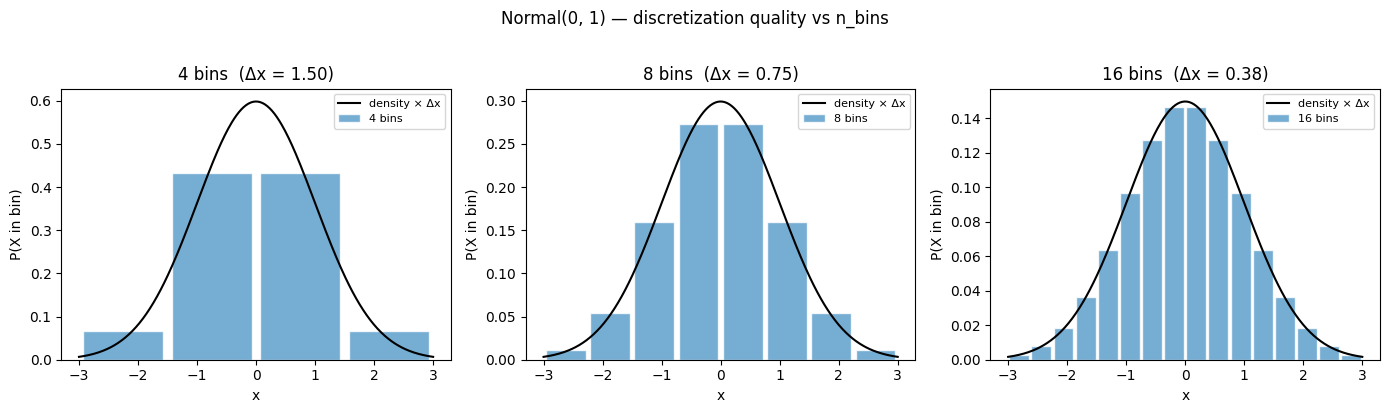

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, n in zip(axes, [4, 8, 16]):
    lo, hi = -3.0, 3.0
    ticks = np.linspace(lo, hi, n + 1)
    mids = (ticks[:-1] + ticks[1:]) / 2
    width = ticks[1] - ticks[0]
    probs = [sp_norm.cdf(ticks[i+1]) - sp_norm.cdf(ticks[i]) for i in range(n)]

    ax.bar(mids, probs, width=width * 0.9, color='#5499C7', alpha=0.8,
           edgecolor='white', label=f'{n} bins')

    xs = np.linspace(lo, hi, 300)
    ax.plot(xs, sp_norm.pdf(xs) * width, 'k-', lw=1.5, label='density × Δx')

    ax.set_title(f'{n} bins  (Δx = {width:.2f})')
    ax.set_xlabel('x')
    ax.set_ylabel('P(X in bin)')
    ax.legend(fontsize=8)

plt.suptitle('Normal(0, 1) — discretization quality vs n_bins', y=1.02)
plt.tight_layout()
plt.show()

## 3. Impact of `n_bins` on precision

The approximation error decreases as `n_bins` grows.

We measure this on a root node `X ~ Normal(20, 5)` and compare the discretized moments to the exact values: `E[X] = 20`, `Std[X] = 5`.

In [3]:
def posterior_stats(p_dict):
    def mid(s):
        lo = float(s.split(';')[0].lstrip('['))
        hi = float(s.split(';')[1].rstrip(']').rstrip('['))
        return (lo + hi) / 2
    vals = [(mid(k), v) for k, v in p_dict.items()]
    e1 = sum(m * p for m, p in vals)
    e2 = sum(m**2 * p for m, p in vals)
    return e1, (e2 - e1**2) ** 0.5

true_mean, true_std = 20.0, 5.0

print(f"{'n_bins':>7}  {'E[X]':>8}  {'Std[X]':>8}  {'err_mean':>9}  {'err_std':>8}")
print(f"{'exact':>7}  {true_mean:>8.3f}  {true_std:>8.3f}")
print('-' * 52)

for n in [3, 5, 8, 12, 20, 32]:
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        bn = BNppl()
        bn.sample('x', Normal(true_mean, true_std))
        bn.compile(n_bins=n)
    p = bn.query('x')
    e, s = posterior_stats(p)
    print(f"{n:>7}  {e:>8.3f}  {s:>8.3f}  {abs(e - true_mean):>9.4f}  {abs(s - true_std):>8.4f}")

 n_bins      E[X]    Std[X]   err_mean   err_std
  exact    20.000     5.000
----------------------------------------------------
      3    20.000     5.617     0.0000    0.6166
      5    20.000     5.215     0.0000    0.2146
      8    20.000     5.044     0.0000    0.0444
     12    20.000     4.983     0.0000    0.0173
     20    20.000     4.951     0.0000    0.0491
     32    20.000     4.940     0.0000    0.0601


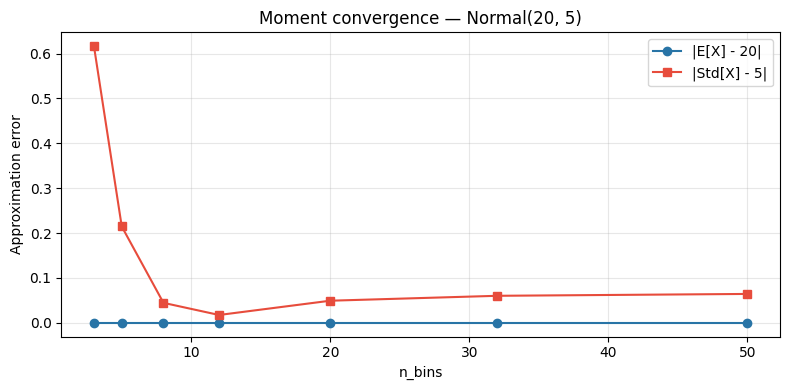

In [4]:
ns = [3, 5, 8, 12, 20, 32, 50]
errors_mean, errors_std = [], []

for n in ns:
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        bn = BNppl()
        bn.sample('x', Normal(true_mean, true_std))
        bn.compile(n_bins=n)
    p = bn.query('x')
    e, s = posterior_stats(p)
    errors_mean.append(abs(e - true_mean))
    errors_std.append(abs(s - true_std))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns, errors_mean, 'o-', color='#2874A6', label='|E[X] - 20|')
ax.plot(ns, errors_std,  's-', color='#E74C3C', label='|Std[X] - 5|')
ax.set_xlabel('n_bins')
ax.set_ylabel('Approximation error')
ax.set_title('Moment convergence — Normal(20, 5)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. MIDPOINT vs INTEGRATION

For nodes with **continuous parents**, the CPT entry `P(X ∈ bin_i | Y ∈ bin_j)` can be computed two ways:

- **MIDPOINT**: evaluates the distribution at the center of the parent bin.  
  `P(X ∈ bin_i | Y ∈ bin_j) ≈ P(X ∈ bin_i | Y = midpoint_j)`  

- **INTEGRATION**: numerically integrates over the parent bin:  
  `P(X ∈ bin_i | Y ∈ bin_j) = (1/Δy) ∫ [F(x_hi|y) − F(x_lo|y)] dy`  

**When INTEGRATION is better:** when the `Y → X` relationship is **non-linear**.  
With a convex function like `exp`, the bin midpoint does not represent the bin mean well — this is **Jensen's inequality**:

$$E[f(Y)] \geq f(E[Y]) \quad \text{if } f \text{ is convex}$$

MIDPOINT evaluates `f(midpoint)` = `f(E[Y])`, which **underestimates** the true mean when `f` is convex.  
INTEGRATION computes `(1/Δy) ∫ f(y) dy`, a true bin average — much closer to the actual value.

**For smooth Gaussian models** (`X | μ ~ Normal(μ, σ)`), the relationship is linear in μ — Jensen does not apply — and both methods are comparable.

In [5]:
# Model: Y ~ Uniform(-1, 1),  X | Y ~ Normal(exp(Y), 0.5)
# Non-linear relationship: X's mean depends on exp(Y), a convex function.
#
# E[X] exact = E[exp(Y)] for Y ~ Uniform(-1, 1)
#            = integral_{-1}^{1} exp(y)/2 dy = (e - 1/e) / 2 ≈ 1.1752
#
# Jensen: E[exp(Y)] > exp(E[Y]) = exp(0) = 1.0
# -> MIDPOINT underestimates E[X] by evaluating exp(midpoint) = exp(0) = 1.0
# -> INTEGRATION integrates exp(y) over each bin -> stays close to 1.1752

true_e_x = (np.e - 1.0 / np.e) / 2

print(f'E[X] exact = (e - 1/e)/2 = {true_e_x:.4f}\n')
print(f"{'n_bins':>7}  {'MIDPOINT':>10}  {'INTEGRATION':>13}  {'err_mid':>9}  {'err_int':>9}")
print('-' * 58)

for n in [2, 4, 6, 8, 12]:
    means = {}
    for method in (MIDPOINT, INTEGRATION):
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            bn = BNppl()
            y  = bn.sample('y', Uniform(-1.0, 1.0))
            x  = bn.sample('x', lambda v: Normal(np.exp(v), 0.5), parents=[y])
            bn.compile(n_bins=n, estimate_proba_method=method)
        e, _ = posterior_stats(bn.query('x'))
        means[method] = e

    em = abs(means[MIDPOINT]    - true_e_x)
    ei = abs(means[INTEGRATION] - true_e_x)
    print(f"{n:>7}  {means[MIDPOINT]:>10.4f}  {means[INTEGRATION]:>13.4f}  {em:>9.4f}  {ei:>9.4f}")

print('\n-> INTEGRATION stays close to the exact value (integrates over the bin)')
print('-> MIDPOINT underestimates E[X] due to Jensen (exp is convex, midpoint != true bin mean)')
print('-> For n_bins >= 8, both methods converge.')

E[X] exact = (e - 1/e)/2 = 1.1752

 n_bins    MIDPOINT    INTEGRATION    err_mid    err_int
----------------------------------------------------------
      2      1.0270         1.0437     0.1482     0.1315
      4      1.1694         1.1808     0.0058     0.0056
      6      1.1701         1.1755     0.0051     0.0003
      8      1.1725         1.1755     0.0027     0.0003
     12      1.1742         1.1755     0.0010     0.0003

-> INTEGRATION stays close to the exact value (integrates over the bin)
-> MIDPOINT underestimates E[X] due to Jensen (exp is convex, midpoint != true bin mean)
-> For n_bins >= 8, both methods converge.


## 5. CPT combinatorial explosion

CPT size for a node X with k continuous parents, each with `n_bins` states:

$$\text{CPT entries} = n\_bins^{k+1}$$

This growth is **exponential** in k — the main limiting factor in continuous modelling.

In [6]:
n_bins_vals = [4, 8, 12, 16]
k_vals      = [0, 1, 2, 3]

header = f"{'k parents':>10}" + ''.join(f"  {'n='+str(n):>8}" for n in n_bins_vals)
print(header)
print('-' * len(header))
for k in k_vals:
    row = f"{k:>10}" + ''.join(f"  {n**(k+1):>8,}" for n in n_bins_vals)
    print(row)

 k parents       n=4       n=8      n=12      n=16
--------------------------------------------------
         0         4         8        12        16
         1        16        64       144       256
         2        64       512     1,728     4,096
         3       256     4,096    20,736    65,536


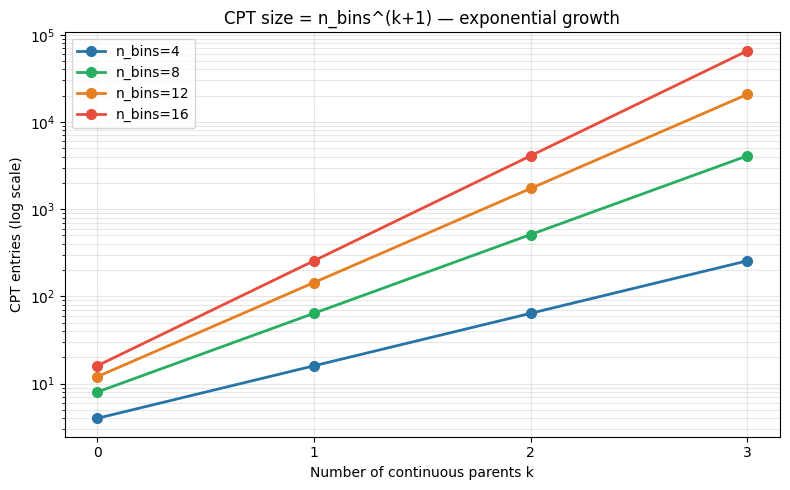

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#2874A6', '#27AE60', '#E67E22', '#E74C3C']

for n, color in zip(n_bins_vals, colors):
    entries = [n**(k+1) for k in k_vals]
    ax.plot(k_vals, entries, 'o-', color=color, label=f'n_bins={n}', linewidth=2, markersize=7)

ax.set_yscale('log')
ax.set_xlabel('Number of continuous parents k')
ax.set_ylabel('CPT entries (log scale)')
ax.set_title('CPT size = n_bins^(k+1) — exponential growth')
ax.set_xticks(k_vals)
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

## 6. BIN_ADAPTIVE — automatic reduction

`BIN_ADAPTIVE` automatically reduces the number of bins for nodes with many continuous parents:

| Continuous parents k | Formula | Effective bins (global=10) |
|---|---|---|
| 0 or 1 | `n_bins` | 10 |
| 2 | `n_bins // 2` | 5 |
| 3 | `max(3, n_bins // 4)` | 3 |

The idea: root nodes and nodes with few parents keep full precision. Heavily connected nodes accept a slight precision loss to remain compilable quickly.

In [8]:
print(f"{'Strategy':<22} {'n':>4}  {'bins(x)':>8}  {'CPT(x)':>8}  {'E[mu|x=max]':>13}\n")

for strat_name, strategy in [('BIN_UNIFORM', BIN_UNIFORM), ('BIN_ADAPTIVE', BIN_ADAPTIVE)]:
    for n in [6, 10]:
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            bn = BNppl()
            mu    = bn.sample('mu',    Normal(0.0, 1.0))
            sigma = bn.sample('sigma', Uniform(0.5, 2.0))
            x     = bn.sample('x', lambda m, s: Normal(m, max(0.1, s)), parents=[mu, sigma])
            bn.compile(n_bins=n, bin_strategy=strategy)

        n_x  = bn.gum_bn.variable('x').domainSize()
        n_mu = bn.gum_bn.variable('mu').domainSize()
        n_sg = bn.gum_bn.variable('sigma').domainSize()
        cpt  = n_x * n_mu * n_sg

        p_mu    = bn.query('mu', evidence={'x': n_x - 1})
        e_mu, _ = posterior_stats(p_mu)

        print(f'  {strat_name:<20} {n:>4}  {n_x:>8}  {cpt:>8,}  {e_mu:>13.3f}')
    print()

print('-> BIN_ADAPTIVE halves CPT(x) (n=6) or more (n=10),')
print('   with a small precision loss on E[mu|x=max].')

Strategy                  n   bins(x)    CPT(x)    E[mu|x=max]

  BIN_UNIFORM             6         6       216          1.559
  BIN_UNIFORM            10        10     1,000          1.647

  BIN_ADAPTIVE            6         3       108          1.191
  BIN_ADAPTIVE           10         5       500          1.424

-> BIN_ADAPTIVE halves CPT(x) (n=6) or more (n=10),
   with a small precision loss on E[mu|x=max].


## 7. `memory_warn_mb` and `memory_limit_mb`

Two parameters protect against accidentally building very large BNs:

- **`memory_warn_mb`** (default 50.0): prints a warning and per-node breakdown if total CPT size exceeds this threshold.
- **`memory_limit_mb`**: raises a `RuntimeError` and aborts compilation if the threshold is exceeded.

Useful for catching a problematic `n_bins` × `k parents` combination early.

In [9]:
# Trigger a warning with a very low threshold
bn_warn = BNppl()
mu    = bn_warn.sample('mu',    Normal(0.0, 1.0))
sigma = bn_warn.sample('sigma', Uniform(0.5, 2.0))
x     = bn_warn.sample('x', lambda m, s: Normal(m, max(0.1, s)), parents=[mu, sigma])
bn_warn.compile(n_bins=15, memory_warn_mb=0.01)

C:\Users\louto\AppData\Local\Temp\ipykernel_26248\1686127763.py:6: UserWarning: [WARN] Large BN (0.027 MB > warn threshold 0.010 MB).
Top-3 nodes by CPT size:
  x                                 3,375 entries  (2 parents)
  sigma                                15 entries  (0 parents)
  mu                                   15 entries  (0 parents)
Suggestions:
- Reduce n_bins (currently 15)
- Switch to bin_strategy=BIN_ADAPTIVE or BIN_MEMORY_BUDGET
- Per-node override: bn.sample('x', ..., n_bins=5)
  bn_warn.compile(n_bins=15, memory_warn_mb=0.01)


In [10]:
# Trigger an error with memory_limit_mb
try:
    bn_lim = BNppl()
    mu    = bn_lim.sample('mu',    Normal(0.0, 1.0))
    sigma = bn_lim.sample('sigma', Uniform(0.5, 2.0))
    x     = bn_lim.sample('x', lambda m, s: Normal(m, max(0.1, s)), parents=[mu, sigma])
    bn_lim.compile(n_bins=15, memory_limit_mb=0.001)
except RuntimeError as e:
    print(f'RuntimeError:\n{e}')

RuntimeError:
Compilation aborted: BN requires 0.027 MB which exceeds memory_limit_mb=0.001 MB.
Largest nodes: x (3,375 entries), sigma (15 entries), mu (15 entries)
Suggestions:
- Reduce n_bins (currently 15)
- Use bin_strategy=BIN_ADAPTIVE
- Use per-node override: bn.sample(..., n_bins=5)
